# explore — general-purpose data explorer

Scatter with column-mapped visual channels and optional per-column faceting.

```
explore(x_or_data, y=None, *, x, y_col, color, size, facet,
        opacity, width, height, padding, interactive) -> np.ndarray | None
```

| Parameter | Accepts | Behaviour |
|-----------|---------|----------|
| `color` | `str` (column) | Categorical — maps unique values to `CLUSTER_PALETTE` |
| `color` | RGB tuple | Uniform colour for all points |
| `color` | `None` | Default `(0.3, 0.6, 1.0)` |
| `size` | `str` (column) | Numeric — linear map to `[2.0, 12.0]` pixel radius |
| `size` | float | Uniform radius |
| `facet` | `str` (column) | One slide per unique value + "All" overview slide |

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
import justviz as jv

## 1 — Uniform color (arrays)

explore: 20,000 points, 900×700, render 243.8ms


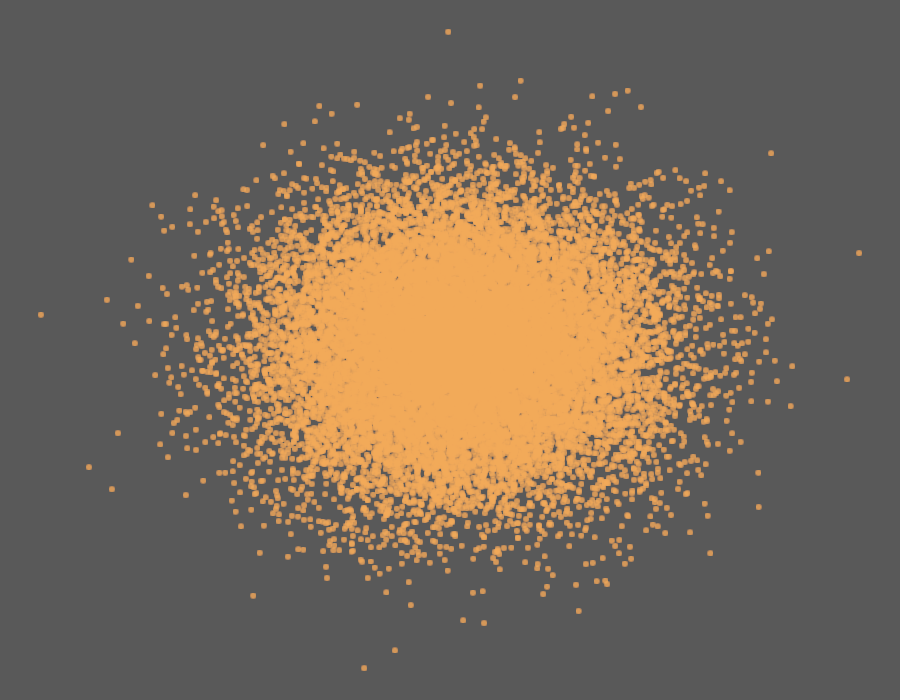

In [2]:
rng = np.random.default_rng(42)
x = rng.normal(0, 1, 20_000).astype(np.float32)
y = rng.normal(0, 1, 20_000).astype(np.float32)

img = jv.explore(x, y, color=(0.9, 0.4, 0.1), size=3.0, opacity=0.7,
                 width=900, height=700)
display(Image.fromarray(img, mode='RGBA'))

## 2 — Categorical color from a DataFrame column

In [ ]:
rng = np.random.default_rng(7)
n = 15_000
species = rng.choice(["setosa", "versicolor", "virginica"], n)

# Species-specific distributions
x_vals, y_vals = [], []
for sp, cx, cy in [("setosa", 0, 5), ("versicolor", 3, 3), ("virginica", 6, 1)]:
    mask = species == sp
    k = mask.sum()
    x_vals.append(rng.normal(cx, 0.5, k))
    y_vals.append(rng.normal(cy, 0.5, k))

df = pd.DataFrame({
    "petal_length": np.concatenate(x_vals).astype(np.float32),
    "petal_width":  np.concatenate(y_vals).astype(np.float32),
    "species":      species,
})

img = jv.explore(df, x="petal_length", y="petal_width",
                 color="species", size=4.0, opacity=0.8,
                 width=900, height=700)
display(Image.fromarray(img, mode='RGBA'))

## 3 — Numeric size mapping from a column

In [ ]:
rng = np.random.default_rng(3)
n = 5_000
df2 = pd.DataFrame({
    "x":      rng.uniform(-5, 5, n).astype(np.float32),
    "y":      rng.uniform(-5, 5, n).astype(np.float32),
    "weight": rng.exponential(1, n).astype(np.float32),  # wide range
})

img = jv.explore(df2, x="x", y="y",
                 color=(0.2, 0.7, 0.9),
                 size="weight",  # radius mapped to [2.0, 12.0]
                 opacity=0.6, width=900, height=700)
display(Image.fromarray(img, mode='RGBA'))

## 4 — Color + size together

In [ ]:
rng = np.random.default_rng(5)
n = 8_000
regions = rng.choice(["North", "South", "East", "West"], n)

df3 = pd.DataFrame({
    "revenue":  rng.uniform(10, 500, n).astype(np.float32),
    "margin":   rng.uniform(0.05, 0.4, n).astype(np.float32),
    "volume":   rng.exponential(500, n).astype(np.float32),
    "region":   regions,
})

img = jv.explore(df3, x="revenue", y="margin",
                 color="region",
                 size="volume",
                 opacity=0.7, width=1100, height=750)
display(Image.fromarray(img, mode='RGBA'))

## 5 — Faceting (one slide per category)

Returns the combined image; in `interactive=True` mode the storyboard opens and
each slide shows only one facet.

In [ ]:
rng = np.random.default_rng(8)
n = 20_000
year = rng.choice([2021, 2022, 2023, 2024], n)

df4 = pd.DataFrame({
    "x":    rng.normal(0, 1, n).astype(np.float32),
    "y":    rng.normal(0, 1, n).astype(np.float32),
    "cat":  rng.choice(["A", "B", "C"], n),
    "year": year,
})

# headless mode returns the all-layers image
img = jv.explore(df4, x="x", y="y",
                 color="cat",
                 facet="year",
                 opacity=0.8, width=1000, height=750)
display(Image.fromarray(img, mode='RGBA'))

## 6 — From a Parquet file

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq

rng = np.random.default_rng(20)
n = 25_000
table = pa.table({
    "x": rng.uniform(-10, 10, n).astype(np.float32),
    "y": rng.uniform(-10, 10, n).astype(np.float32),
})
pq.write_table(table, "/tmp/explore_data.parquet")

img = jv.explore("/tmp/explore_data.parquet", x="x", y="y",
                 color=(0.5, 0.9, 0.4), size=3.0, opacity=0.6,
                 width=900, height=700)
display(Image.fromarray(img, mode='RGBA'))